In [ ]:
# ============================================================================
# IMPORTS
# ============================================================================

# ======================================
# Standard Library
# ======================================
import os
import random
import time
import copy
import warnings
from collections import Counter


warnings.filterwarnings('ignore')

# ======================================
# Data Science & Visualization
# ======================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# Scikit-Learn - Preprocessing
# ======================================
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

# ======================================
# Scikit-Learn - Model Selection
# ======================================
from sklearn.model_selection import train_test_split

# ======================================
# Scikit-Learn - Metrics
# ======================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# ======================================
# Scikit-Learn - Classical ML Models
# ======================================
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# ======================================
# Scikit-Learn - Utilities
# ======================================
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

# ======================================
# Gradient Boosting Libraries
# ======================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ======================================
# TensorFlow & Keras (Deep Learning)
# ======================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ======================================
# PyTorch (Deep Learning)
# ======================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ======================================
# Reproducibility Setup
# ======================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set TensorFlow seed
tf.random.set_seed(SEED)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"✅ All imports loaded successfully!\n")

2025-12-16 16:48:51.949077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765903732.217329      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765903732.289432      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cpu
TensorFlow version: 2.18.0
PyTorch version: 2.6.0+cu124
✅ All imports loaded successfully!



In [4]:
# ============================================================================
# LOAD AND MERGE DATASETS
# ============================================================================

print("="*80)
print("LOADING AND MERGING DATASETS")
print("="*80)

benign_dfs = []
for i in range(1, 11):
    file_path = f'/kaggle/input/iiot-dataset-final/benign_samples_{i}sec.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        print(f"✓ Loaded benign_samples_{i}sec.csv - Shape: {df.shape}")
        benign_dfs.append(df)

benign_data = pd.concat(benign_dfs, ignore_index=True)
print(f"\n✓ Combined benign dataset: {benign_data.shape}")

attack_dfs = []
for i in range(1, 11):
    file_path = f'/kaggle/input/iiot-dataset-final/attack_samples_{i}sec.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        print(f"✓ Loaded attack_samples_{i}sec.csv - Shape: {df.shape}")
        attack_dfs.append(df)

attack_data = pd.concat(attack_dfs, ignore_index=True)
print(f"✓ Combined attack dataset: {attack_data.shape}")


LOADING AND MERGING DATASETS
✓ Loaded benign_samples_1sec.csv - Shape: (136800, 94)
✓ Loaded benign_samples_2sec.csv - Shape: (68400, 94)
✓ Loaded benign_samples_3sec.csv - Shape: (45600, 94)
✓ Loaded benign_samples_4sec.csv - Shape: (34200, 94)
✓ Loaded benign_samples_5sec.csv - Shape: (27360, 94)
✓ Loaded benign_samples_6sec.csv - Shape: (22800, 94)
✓ Loaded benign_samples_7sec.csv - Shape: (19532, 94)
✓ Loaded benign_samples_8sec.csv - Shape: (17100, 94)
✓ Loaded benign_samples_9sec.csv - Shape: (15200, 94)
✓ Loaded benign_samples_10sec.csv - Shape: (13680, 94)

✓ Combined benign dataset: (400672, 94)
✓ Loaded attack_samples_1sec.csv - Shape: (90391, 94)
✓ Loaded attack_samples_2sec.csv - Shape: (44744, 94)
✓ Loaded attack_samples_3sec.csv - Shape: (29627, 94)
✓ Loaded attack_samples_4sec.csv - Shape: (22165, 94)
✓ Loaded attack_samples_5sec.csv - Shape: (17695, 94)
✓ Loaded attack_samples_6sec.csv - Shape: (14723, 94)
✓ Loaded attack_samples_7sec.csv - Shape: (12050, 94)
✓ Loaded a

In [5]:
print(f"Benign dataset shape: {benign_data.shape}")
print(f"Attack dataset shape: {attack_data.shape}")

Benign dataset shape: (400672, 94)
Attack dataset shape: (284999, 94)


In [6]:
def extract_attack_type(label2):
    if pd.isna(label2) or label2 == 'benign':
        return 'benign'
    return str(label2).lower()

benign_data['attack'] = 'benign'
attack_data['attack'] = attack_data['label2'].apply(extract_attack_type)

In [7]:
# Display attack type distribution
print("\nAttack type distribution:")
print(attack_data['attack'].value_counts())


Attack type distribution:
attack
recon         105848
dos            57736
ddos           56692
mitm           25490
malware        24177
web             9040
bruteforce      6016
Name: count, dtype: int64


In [8]:
merged_data = pd.concat([benign_data, attack_data], ignore_index=True)
print(f"\n✓ Merged dataset: {merged_data.shape}")


✓ Merged dataset: (685671, 95)


In [9]:
merged_data.head()

,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,attack
0,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:40.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:40.400000Z,2025-09-09T14:09:41.400000Z,...,0.006059,62.800000,64.0,61.0,1.469694,1870.500000,3081.0,660.0,1210.500000,benign
1,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:41.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:41.400000Z,2025-09-09T14:09:42.400000Z,...,0.016469,62.500000,64.0,61.0,1.500000,1870.500000,3081.0,660.0,1210.500000,benign
2,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:42.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:42.400000Z,2025-09-09T14:09:43.400000Z,...,0.034312,61.571429,64.0,53.0,3.736199,2441.285714,4736.0,135.0,1813.237335,benign
3,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:43.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:43.400000Z,2025-09-09T14:09:44.400000Z,...,0.012790,62.500000,64.0,61.0,1.500000,1870.500000,3081.0,660.0,1210.500000,benign
4,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:44.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:44.400000Z,2025-09-09T14:09:45.400000Z,...,0.017764,62.800000,64.0,61.0,1.469694,2112.600000,3081.0,660.0,1186.042933,benign


In [10]:
# Check for missing values
missing_percent = (merged_data.isnull().sum() / len(merged_data)) * 100
if missing_percent.sum() > 0:
    print("\nMissing values (%):")
    print(missing_percent[missing_percent > 0])
else:
    print("\nNo missing values detected!")


No missing values detected!



EDA - CLASS DISTRIBUTION

 Attack Distribution:
   benign         :  400,672 (58.44%)
   recon          :  105,848 (15.44%)
   dos            :   57,736 ( 8.42%)
   ddos           :   56,692 ( 8.27%)
   mitm           :   25,490 ( 3.72%)
   malware        :   24,177 ( 3.53%)
   web            :    9,040 ( 1.32%)
   bruteforce     :    6,016 ( 0.88%)

 Imbalance Ratio: 66.60:1


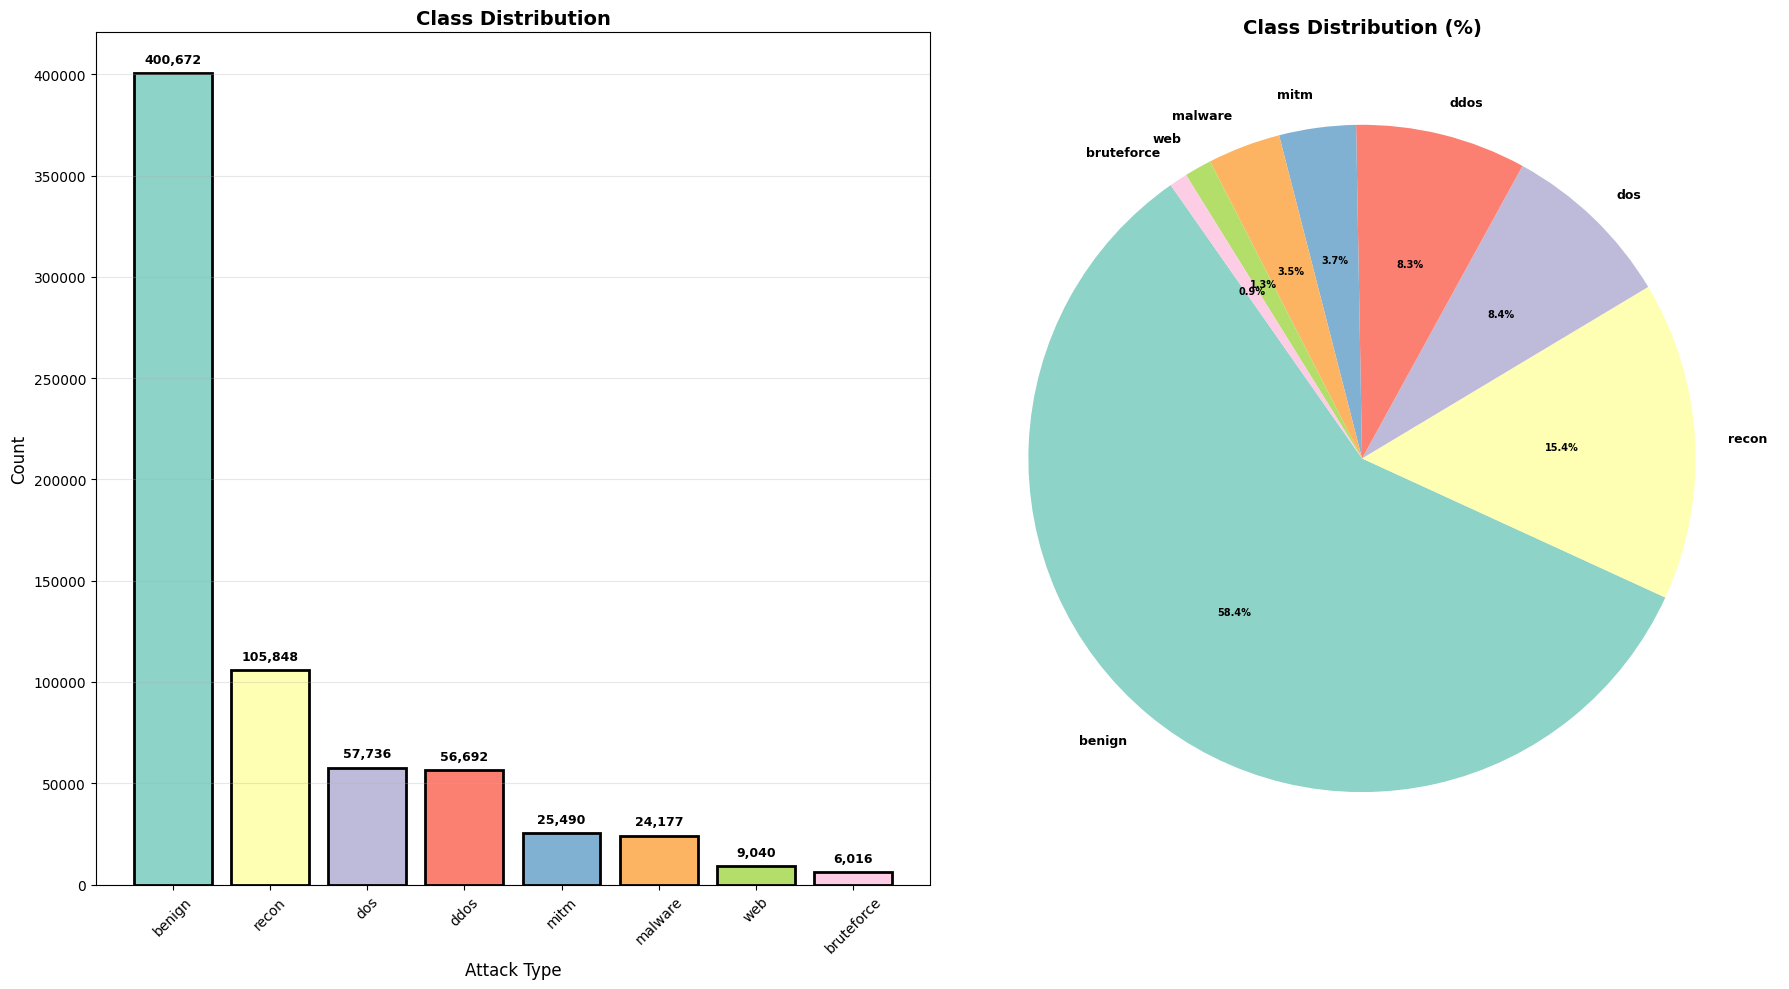

In [11]:
# ============================================================================
# EDA - DATA DISTRIBUTION
# ============================================================================

print("\n" + "="*80)
print("EDA - CLASS DISTRIBUTION")
print("="*80)

attack_counts = merged_data['attack'].value_counts()
print("\n Attack Distribution:")
for attack, count in attack_counts.items():
    pct = 100 * count / len(merged_data)
    print(f"   {attack:15s}: {count:8,} ({pct:5.2f}%)")

# Calculate imbalance ratio
max_class = attack_counts.max()
min_class = attack_counts.min()
imbalance_ratio = max_class / min_class
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Bar plot
colors = plt.cm.Set3(range(len(attack_counts)))
axes[0].bar(attack_counts.index, attack_counts.values, color=colors, edgecolor='black', linewidth=2)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Attack Type', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, (attack, count) in enumerate(attack_counts.items()):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=125,
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)

axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

# Make percentage text smaller
for autotext in autotexts:
    autotext.set_fontsize(7)  # smaller percentage font

plt.tight_layout()
plt.show()
plt.show()

In [12]:
# IDENTIFY AND SEPARATE FEATURE TYPES
# ============================================================================

print("\n" + "="*80)
print(" IDENTIFYING FEATURE TYPES")
print("="*80)

metadata_cols = [
    'device_name', 'device_mac',
    'label_full', 'label1', 'label2', 'label3', 'label4',
    'timestamp', 'timestamp_start', 'timestamp_end'
]

# Define features and target FIRST
X = merged_data.drop(columns=metadata_cols + ['attack'], errors='ignore')
y = merged_data['attack']

# Now detect types ONLY from X
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")



 IDENTIFYING FEATURE TYPES

Numeric features: 71
Categorical features: 13


In [13]:
print(f"\nFeatures after cleaning: {X.shape[1]}")
print(f"Sample size: {X.shape[0]}")


Features after cleaning: 84
Sample size: 685671


In [14]:
# ============================================================================
# CATEGORICAL ENCODING (ORDINAL ENCODER)
# ============================================================================

print("\n" + "="*80)
print(" CATEGORICAL FEATURE ENCODING (ORDINAL)")
print("="*80)

from sklearn.preprocessing import OrdinalEncoder

X_encoded = X.copy()

categorical_features_final = [col for col in categorical_cols if col in X_encoded.columns]
numerical_features_final = [col for col in X_encoded.columns if col not in categorical_features_final]

print(f"\n Encoding {len(categorical_features_final)} categorical features...")

ordinal_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Convert to string & handle NaN
X_encoded[categorical_features_final] = (
    X_encoded[categorical_features_final]
    .fillna('missing')
    .astype(str)
)

X_encoded[categorical_features_final] = ordinal_encoder.fit_transform(
    X_encoded[categorical_features_final]
)

print("✓ Categorical encoding complete")



 CATEGORICAL FEATURE ENCODING (ORDINAL)

 Encoding 13 categorical features...
✓ Categorical encoding complete


In [15]:
# ============================================================================
# PERMUTATION FEATURE IMPORTANCE (LEAKAGE-FREE)
# ============================================================================

print("\n" + "="*80)
print(" PERMUTATION FEATURE IMPORTANCE (FEATURE SELECTION)")
print("="*80)

# ------------------------------------------------------------------
# 1️⃣ Train / Validation split (MANDATORY for feature selection)
# ------------------------------------------------------------------
X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Optional: subsample training set for speed
sample_size = min(50000, len(X_fs_train))
X_fs_train = X_fs_train.sample(n=sample_size, random_state=42)
y_fs_train = y_fs_train.loc[X_fs_train.index]

print(f"✓ Feature selection training samples: {len(X_fs_train)}")

# ------------------------------------------------------------------
# 2️⃣ Data safety (trees tolerate 0-filling)
# ------------------------------------------------------------------
X_fs_train = X_fs_train.apply(pd.to_numeric, errors='coerce')
X_fs_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_fs_train.fillna(0, inplace=True)
X_fs_train = X_fs_train.astype(np.float32)

X_fs_val = X_fs_val.apply(pd.to_numeric, errors='coerce')
X_fs_val.replace([np.inf, -np.inf], np.nan, inplace=True)
X_fs_val.fillna(0, inplace=True)
X_fs_val = X_fs_val.astype(np.float32)

# ------------------------------------------------------------------
# 3️⃣ Train Random Forest (interaction-aware)
# ------------------------------------------------------------------
print("\n ✓ Training Random Forest for permutation importance...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_fs_train, y_fs_train)

# ------------------------------------------------------------------
# 4️⃣ Permutation importance on VALIDATION set
# ------------------------------------------------------------------
print("✓ Computing permutation importance (validation set)...")

perm_importance = permutation_importance(
    rf_model,
    X_fs_val,
    y_fs_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\n✓ Permutation importance computed")
print("\n Top 20 Features:")
print(importance_df.head(20).to_string(index=False))

# ------------------------------------------------------------------
# 5️⃣ Feature selection rule
# ------------------------------------------------------------------
n_features_to_keep = max(70, int(0.7 * len(X_encoded.columns)))

selected_features = importance_df.head(n_features_to_keep)['Feature'].tolist()

X_selected = X_encoded[selected_features].copy()

print(f"\n✓ Selected {len(selected_features)} features")




 PERMUTATION FEATURE IMPORTANCE (FEATURE SELECTION)
✓ Feature selection training samples: 50000

 ✓ Training Random Forest for permutation importance...
✓ Computing permutation importance (validation set)...

✓ Permutation importance computed

 Top 20 Features:
                          Feature  Importance      Std
          network_packet-size_min    0.009440 0.000176
           network_time-delta_avg    0.007151 0.000209
network_window-size_std_deviation    0.001987 0.000052
                 network_macs_src    0.001983 0.000135
           network_time-delta_min    0.001602 0.000091
                network_ports_all    0.000985 0.000081
          network_window-size_min    0.000979 0.000057
                network_ports_src    0.000861 0.000052
            network_ip-length_min    0.000755 0.000053
             network_ip-flags_avg    0.000718 0.000061
 network_time-delta_std_deviation    0.000693 0.000096
                 network_macs_all    0.000679 0.000073
                 netwo

In [16]:
# ============================================================================
# TRAIN/TEST SPLIT (STRATIFIED, LEAKAGE-FREE)
# ============================================================================

print("\n" + "="*80)
print(" TRAIN/TEST SPLIT (Stratified)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✓ Split Complete:")
print(f"   Train: {X_train.shape[0]:,} samples")
print(f"   Test:  {X_test.shape[0]:,} samples")
print(f"   Features: {X_train.shape[1]}")

# ------------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------------
print("\n Class Distribution (Train):")

class_counts = y_train.value_counts(normalize=False)
class_percent = y_train.value_counts(normalize=True) * 100

for cls in class_counts.index:
    print(f"   {str(cls):20s}: {class_counts[cls]:6,} ({class_percent[cls]:5.2f}%)")



 TRAIN/TEST SPLIT (Stratified)

✓ Split Complete:
   Train: 548,536 samples
   Test:  137,135 samples
   Features: 70

 Class Distribution (Train):
   benign              : 320,537 (58.43%)
   recon               : 84,678 (15.44%)
   dos                 : 46,189 ( 8.42%)
   ddos                : 45,353 ( 8.27%)
   mitm                : 20,392 ( 3.72%)
   malware             : 19,342 ( 3.53%)
   web                 :  7,232 ( 1.32%)
   bruteforce          :  4,813 ( 0.88%)


In [17]:
# ============================================================================
# CLASS BALANCING
# ============================================================================

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))


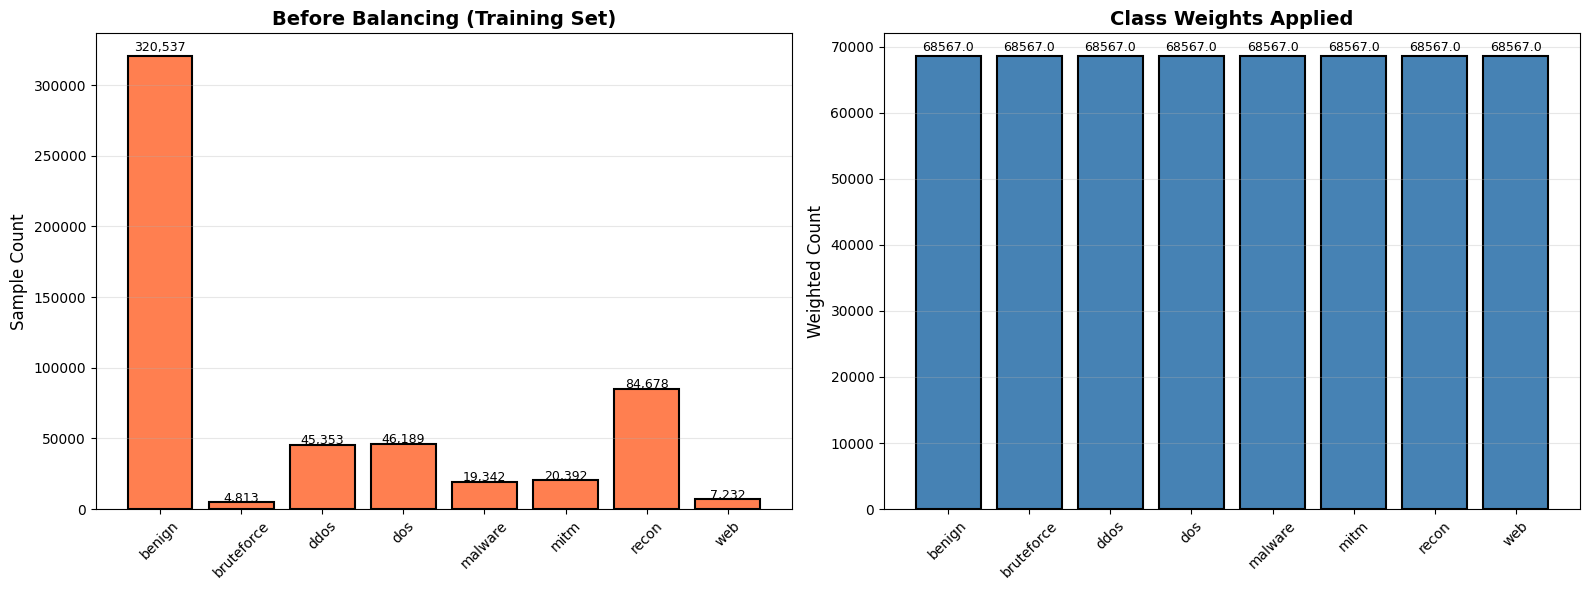

In [18]:
# Classes and counts
train_counts = pd.Series(y_train).value_counts().sort_index()
classes = train_counts.index.astype(str)
weights = np.array([class_weights[c] for c in classes])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------
# Before weighting
# -------------------------------
axes[0].bar(classes, train_counts.values, edgecolor='black', linewidth=1.5, color='coral')
axes[0].set_title('Before Balancing (Training Set)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sample Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

# -------------------------------
# “Effective” after weighting
# -------------------------------
# Scale counts by class weights for visualization
effective_counts = train_counts.values * weights
axes[1].bar(classes, effective_counts, edgecolor='black', linewidth=1.5, color='steelblue')
axes[1].set_title('Class Weights Applied', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Weighted Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(effective_counts):
    axes[1].text(i, v * 1.01, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [19]:
# ============================================================================
# SCALING FEATURES
# ============================================================================

# Automatically detect numeric columns
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Numeric columns found ({len(numeric_cols)}):")
print(numeric_cols)

# Check if any expected columns are missing
missing_cols = [col for col in numeric_cols if col not in X_train.columns]
if missing_cols:
    print(f" Missing columns: {missing_cols}")

# Scale only the numeric columns that exist
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if numeric_cols:
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("✓ Numeric features scaled successfully with StandardScaler.")


Numeric columns found (70):
['network_packet-size_min', 'network_time-delta_avg', 'network_window-size_std_deviation', 'network_macs_src', 'network_time-delta_min', 'network_ports_all', 'network_window-size_min', 'network_ports_src', 'network_ip-length_min', 'network_ip-flags_avg', 'network_time-delta_std_deviation', 'network_macs_all', 'network_macs_dst', 'network_ports_dst', 'network_macs_all_count', 'network_packet-size_avg', 'network_ttl_std_deviation', 'network_ips_dst', 'network_ip-flags_std_deviation', 'network_macs_src_count', 'network_window-size_max', 'network_ip-length_std_deviation', 'network_packets_dst_count', 'network_packets_all_count', 'network_protocols_dst', 'network_tcp-flags_avg', 'network_macs_dst_count', 'network_packet-size_std_deviation', 'log_data-ranges_min', 'log_messages_count', 'network_ports_src_count', 'network_tcp-flags_std_deviation', 'network_payload-length_max', 'log_data-types_count', 'network_ips_dst_count', 'network_packet-size_max', 'network_ttl_

In [20]:
# ============================================================================
# TARGET ENCODING
# ============================================================================
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)


In [21]:
# ============================================================================
# ML MODELS
# ============================================================================
# ======================================
# 1️⃣ Define Models - Group 1 (Classical ML)
# ======================================
models_group1 = {
    "Random Forest": RandomForestClassifier(
        random_state=42, n_estimators=100, class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, class_weight='balanced'
    ),
    "Extra Trees": ExtraTreesClassifier(
        random_state=42, n_estimators=100, class_weight='balanced'
    )
}

# ======================================
# 2️⃣ Define Models - Group 2 (Boosting)
# ======================================
models_group2 = {
    "XGBoost": XGBClassifier( random_state=42),
    "LightGBM": LGBMClassifier(
        random_state=42, class_weight='balanced'
    ),
    "CatBoost": CatBoostClassifier(
      verbose=False,
      random_state=42
    ),
}


In [22]:
# ======================================
# Function: Train, Evaluate, and Visualize
# ======================================
def train_and_evaluate(models_dict, X_train, X_test, y_train, y_test):
    results = []
    for name, model in models_dict.items():
        print(f"\n===== Training {name} =====")

        # Fit model
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Compute metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        # Print metrics
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1_macro:.4f} | F1 (weighted): {f1_weighted:.4f}")
        print("Confusion Matrix:\n", cm)

        # Store results
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1_macro": f1_macro,
            "F1_weighted": f1_weighted
        })

        # Confusion Matrix Heatmap
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()

    # Return summary as DataFrame
    summary = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
    print("\n=== Model Performance Summary ===")
    print(summary[['Model','Accuracy','Precision','Recall','F1_macro','F1_weighted']])
    return summary


================= GROUP 1: Classical Models =================

===== Training Random Forest =====
Accuracy: 0.9721 | Precision: 0.9899 | Recall: 0.9441 | F1-score: 0.9660 | F1 (weighted): 0.9719
Confusion Matrix:
 [[79983     0    22    28    16     4    82     0]
 [  126  1074     0     0     3     0     0     0]
 [  566     2 10722     5     4    26    14     0]
 [  331     0    14 11184     2     4    12     0]
 [  159     5     2     0  4661     2     6     0]
 [  153     2     5     0     4  4925     9     0]
 [ 2043     1     0     8     6     4 19108     0]
 [  153     0     0     0     0     0     0  1655]]


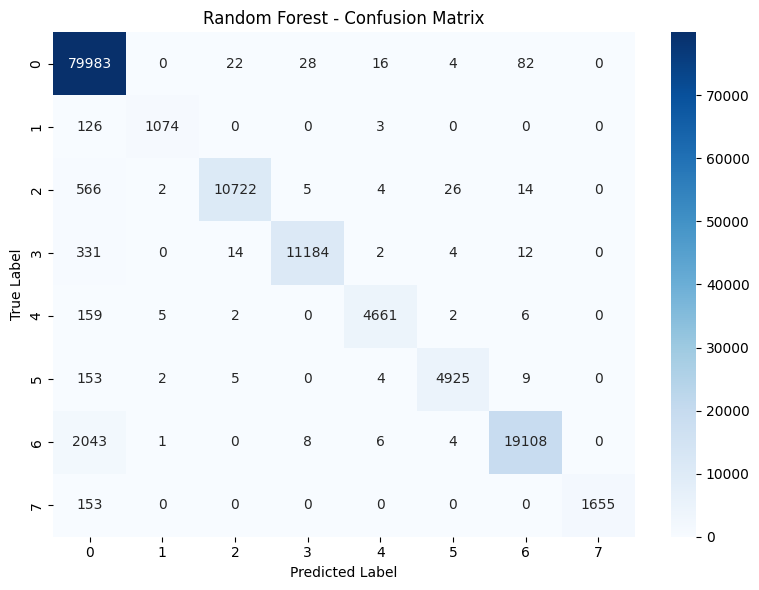


===== Training Decision Tree =====
Accuracy: 0.9700 | Precision: 0.9847 | Recall: 0.9409 | F1-score: 0.9618 | F1 (weighted): 0.9697
Confusion Matrix:
 [[79812     0    58    42    27    13   181     2]
 [  123  1064     5     0     8     0     3     0]
 [  549     2 10707    27    15    21    18     0]
 [  322     1    23 11164     7     5    25     0]
 [  135     5    10     3  4658     7    17     0]
 [  152     4    19     8    15  4880    20     0]
 [ 2019     1    10    22    20    18 19078     2]
 [  155     0     0     0     0     0     1  1652]]


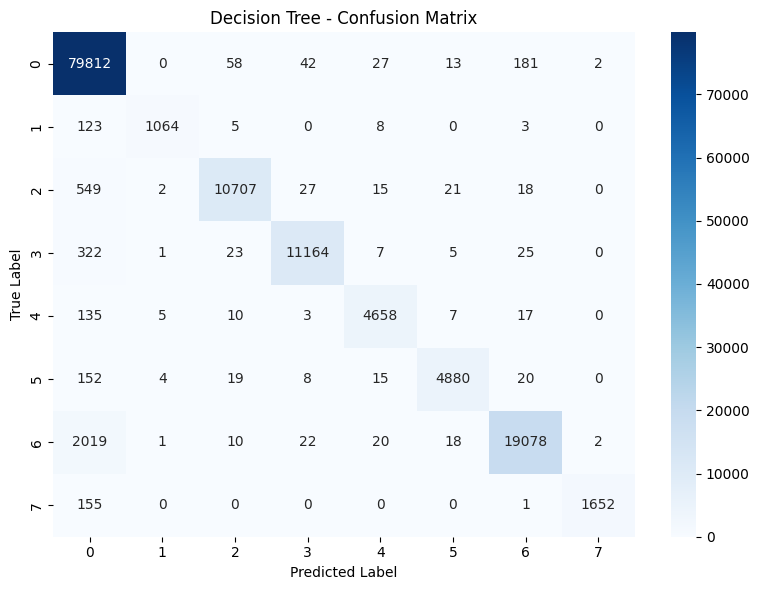


===== Training Extra Trees =====
Accuracy: 0.9714 | Precision: 0.9894 | Recall: 0.9425 | F1-score: 0.9649 | F1 (weighted): 0.9711
Confusion Matrix:
 [[79970     0    30    27    18     5    85     0]
 [  126  1071     0     0     3     3     0     0]
 [  583     2 10691    10    11    35     7     0]
 [  331     0    13 11187     2     4    10     0]
 [  171     2     4     0  4649     2     7     0]
 [  178     2     4     0     2  4905     7     0]
 [ 2058     0     3    10     8     4 19086     1]
 [  153     0     0     1     0     0     0  1654]]


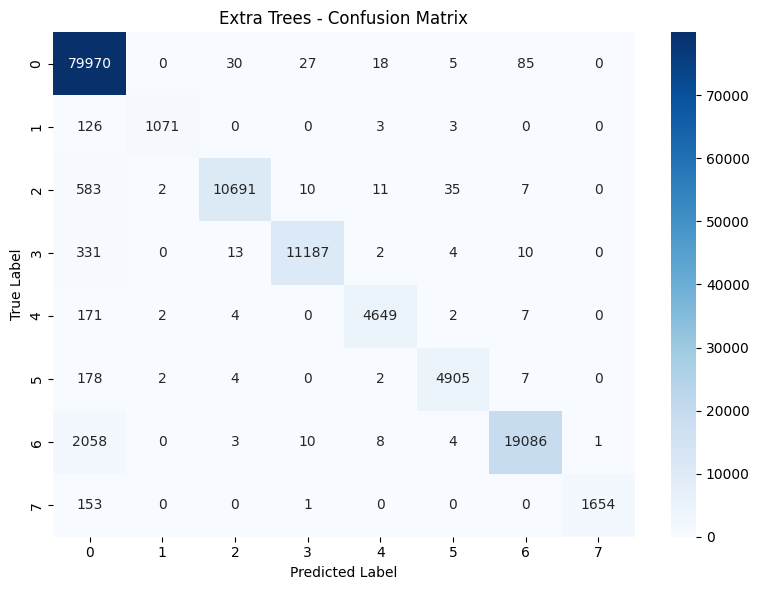


=== Model Performance Summary ===
           Model  Accuracy  Precision    Recall  F1_macro  F1_weighted
0  Random Forest  0.972122   0.989868  0.944134  0.965970     0.971862
2    Extra Trees  0.971400   0.989418  0.942493  0.964865     0.971130
1  Decision Tree  0.969957   0.984677  0.940881  0.961787     0.969668


In [23]:
# ======================================
# 3️⃣ Train & Evaluate Group 1
# ======================================
print("\n================= GROUP 1: Classical Models =================")
summary_group1 = train_and_evaluate(models_group1, X_train_scaled, X_test_scaled, y_train, y_test)


================= GROUP 2: Boosting Models =================

===== Training XGBoost =====
Accuracy: 0.9652 | Precision: 0.9893 | Recall: 0.9367 | F1-score: 0.9616 | F1 (weighted): 0.9646
Confusion Matrix:
 [[80029     0     1     0     5     2    96     2]
 [  124  1075     1     1     2     0     0     0]
 [  657     2 10612    14     5    28    21     0]
 [  343     2    21 11159     2     4    16     0]
 [  174     0     1     0  4645     3    12     0]
 [  168     0     5     3     4  4909     9     0]
 [ 2874     1     1     7     5     4 18278     0]
 [  159     0     0     0     0     0     0  1649]]


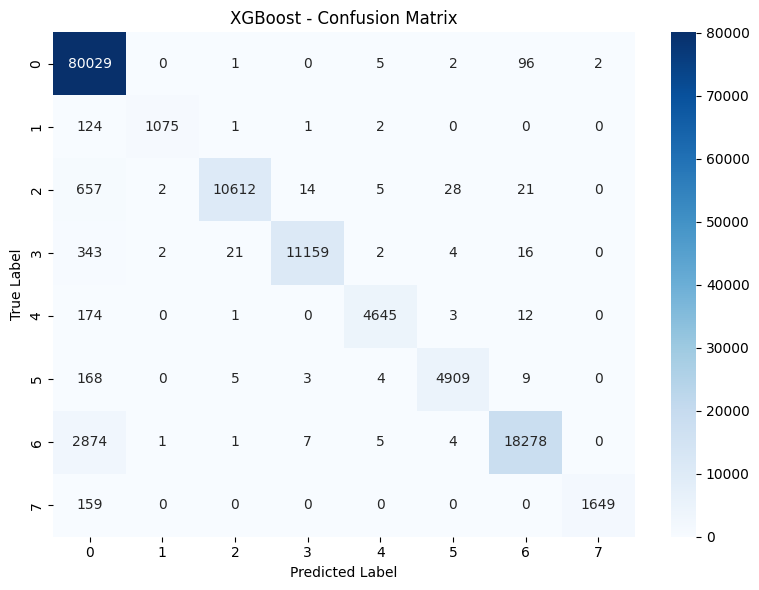


===== Training LightGBM =====
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13114
[LightGBM] [Info] Number of data points in the train set: 548536, number of used features: 70
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
Accuracy: 0.9623 | Precision: 0.9772 | Recall: 0.9395 | F1-score: 0.9575 | F1 (weighted): 0.9619
Confusion Matrix:
 [[79314    17    16    18   105    29   615    21]
 [  123  1077  

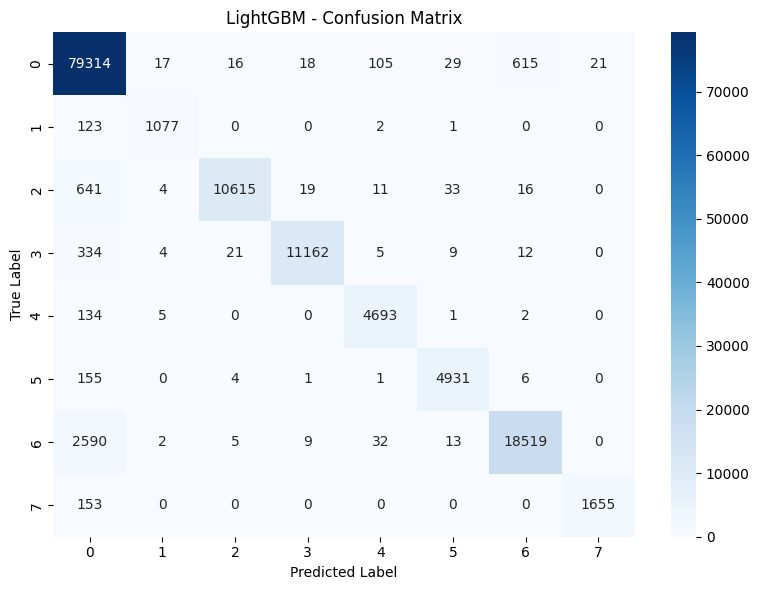


===== Training CatBoost =====
Accuracy: 0.9633 | Precision: 0.9829 | Recall: 0.9299 | F1-score: 0.9550 | F1 (weighted): 0.9628
Confusion Matrix:
 [[80015     0     0     1     2     5   108     4]
 [  131  1058     1     0     7     2     0     4]
 [  690     7 10502    29    17    57    37     0]
 [  352     9    29 11122     1     9    25     0]
 [  184     9     6     2  4611     6    17     0]
 [  169     4    11     2     8  4883    21     0]
 [ 2839     4     3     9     8    14 18293     0]
 [  187     0     0     0     0     0     0  1621]]


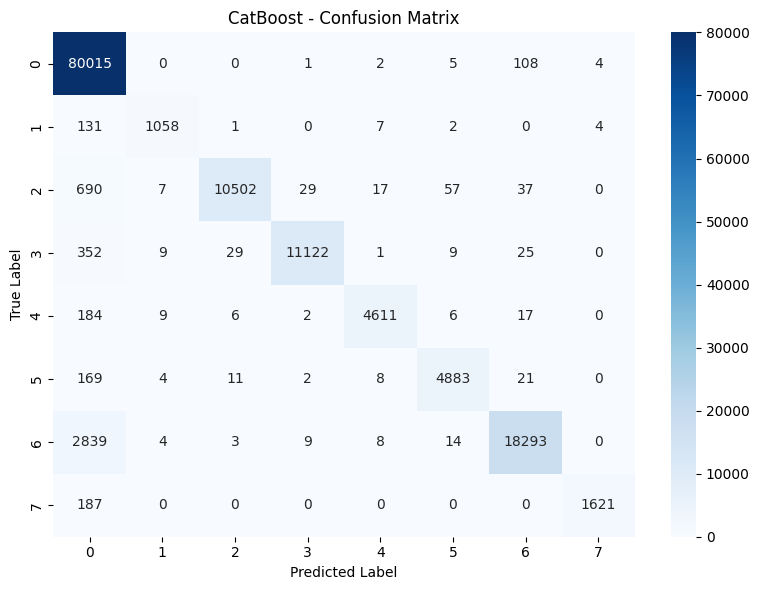


=== Model Performance Summary ===
      Model  Accuracy  Precision    Recall  F1_macro  F1_weighted
0   XGBoost  0.965151   0.989289  0.936705  0.961551     0.964641
1  LightGBM  0.962307   0.977168  0.939481  0.957479     0.961912
2  CatBoost  0.963321   0.982907  0.929940  0.954963     0.962777


In [24]:
# ======================================
# 4️⃣ Train & Evaluate Group 2
# ======================================
print("\n================= GROUP 2: Boosting Models =================")
summary_group2 = train_and_evaluate(models_group2, X_train_scaled, X_test_scaled, y_train, y_test)

In [25]:
# ============================================================================
# DEEP LEARNING MODELS - TENSORFLOW & PYTORCH
# ============================================================================
# ======================================
# Prepare Data for Deep Learning
# ======================================
print("\n" + "="*80)
print("PREPARING DATA FOR DEEP LEARNING")
print("="*80)

# Convert to numpy arrays
X_train_dl = X_train_scaled.values.astype(np.float32)
X_test_dl = X_test_scaled.values.astype(np.float32)
y_train_dl = y_train.astype(np.int32)
y_test_dl = y_test.astype(np.int32)

n_features = X_train_dl.shape[1]
n_classes = len(np.unique(y_train_dl))

print(f"✓ Training samples: {X_train_dl.shape[0]:,}")
print(f"✓ Test samples: {X_test_dl.shape[0]:,}")
print(f"✓ Features: {n_features}")
print(f"✓ Classes: {n_classes}")


PREPARING DATA FOR DEEP LEARNING
✓ Training samples: 548,536
✓ Test samples: 137,135
✓ Features: 70
✓ Classes: 8


In [36]:
# ======================================
# 1️⃣ MLP (No Attention) - Basic Deep Network
# ======================================
print("\n" + "="*80)
print("MODEL 1: MLP (No Attention)")
print("="*80)

def create_mlp_basic(input_dim, num_classes):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation="relu")(x)


    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MLP_Basic')
    return model

mlp_basic = create_mlp_basic(n_features, n_classes)
mlp_basic.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
start_time = time.time()
history_mlp_basic = mlp_basic.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

mlp_basic_time = time.time() - start_time

y_pred_mlp_basic = mlp_basic.predict(X_test_dl).argmax(axis=1)
print(f"\n✓ MLP Basic trained in {mlp_basic_time:.2f}s")



MODEL 1: MLP (No Attention)
Epoch 1/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.9036 - loss: 0.3588 - val_accuracy: 0.9368 - val_loss: 0.2396 - learning_rate: 0.0010
Epoch 2/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9376 - loss: 0.2358 - val_accuracy: 0.9454 - val_loss: 0.2086 - learning_rate: 0.0010
Epoch 3/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.9425 - loss: 0.2178 - val_accuracy: 0.9474 - val_loss: 0.2032 - learning_rate: 0.0010
Epoch 4/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9450 - loss: 0.2094 - val_accuracy: 0.9413 - val_loss: 0.2308 - learning_rate: 0.0010
Epoch 5/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9465 - loss: 0.2040 - val_accuracy: 0.9487 - val_loss: 0.1980 - learning_rate: 0.0010
Epoch 6/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.9473 - loss: 0.2008 - val_accuracy: 0.9500 - val_loss: 0.1951 - learning_rate: 0.0010
Epoch 7/100
3429/3429 ━━━━━━━━━━━━━

In [37]:
# ======================================
# 2️⃣ MLP + Attention Mechanism
# ======================================
print("\n" + "="*80)
print("MODEL 2: MLP + Attention")
print("="*80)

class AttentionLayer(layers.Layer):
    def __init__(self, units):
        super(AttentionLayer, self).__init__()
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, inputs):
        # inputs shape: (batch, features)
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context = attention_weights * inputs
        return context

def create_mlp_attention(input_dim, num_classes):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    # Apply attention
    attention = AttentionLayer(512)(x)
    x = layers.Concatenate()([x, attention])

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MLP_Attention')
    return model

mlp_attention = create_mlp_attention(n_features, n_classes)
mlp_attention.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_mlp_attention = mlp_attention.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)
mlp_attention_time = time.time() - start_time

y_pred_mlp_attention = mlp_attention.predict(X_test_dl).argmax(axis=1)
print(f"\n✓ MLP + Attention trained in {mlp_attention_time:.2f}s")


MODEL 2: MLP + Attention
Epoch 1/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 60s 16ms/step - accuracy: 0.9040 - loss: 0.3632 - val_accuracy: 0.9383 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 2/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - accuracy: 0.9385 - loss: 0.2308 - val_accuracy: 0.9448 - val_loss: 0.2156 - learning_rate: 0.0010
Epoch 3/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.9430 - loss: 0.2155 - val_accuracy: 0.9466 - val_loss: 0.2049 - learning_rate: 0.0010
Epoch 4/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - accuracy: 0.9454 - loss: 0.2071 - val_accuracy: 0.9460 - val_loss: 0.2052 - learning_rate: 0.0010
Epoch 5/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - accuracy: 0.9475 - loss: 0.2011 - val_accuracy: 0.9480 - val_loss: 0.2030 - learning_rate: 0.0010
Epoch 6/100
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - accuracy: 0.9484 - loss: 0.1965 - val_accuracy: 0.9493 - val_loss: 0.1951 - learning_rate: 0.0010
Epoch 7/100
3429/3429 ━━━━━━━━━━

In [123]:
# -----------------------------
# 3️⃣ TabFormer+ Attention 
# -----------------------------

print("\n" + "="*80)
print("MODEL 3: TabFormer + Attention ")
print("="*80)
# ----------------
# -----------------------------
# TabFormer-like Model
# -----------------------------
class TabFormer(Model):
    def __init__(self, input_dim, num_classes, num_heads=4, key_dim=32, ff_dim=64, dropout_rate=0.2, name="TabFormer_TF"):
        super(TabFormer, self).__init__(name=name)
        self.input_dim = input_dim
        
        # Input embedding for features
        self.feature_embedding = layers.Dense(key_dim, activation='relu')
        
        # Multi-Head Self-Attention across features
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        
        # Feed-forward block
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(key_dim)
        ])
        
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()
        
        # Classification head
        self.global_pool = layers.GlobalAveragePooling1D()
        self.dropout = layers.Dropout(dropout_rate)
        self.fc_out = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        # inputs: [batch_size, num_features]
        x = self.feature_embedding(inputs)  # [batch_size, num_features, key_dim]
        x = tf.expand_dims(x, axis=1)       # [batch_size, 1, num_features*key_dim] → treat features as sequence

        # Multi-Head Attention
        attn_out = self.mha(x, x)
        x = self.layernorm1(x + attn_out)
        
        # Feed-forward
        ffn_out = self.ffn(x, training=training)
        x = self.layernorm2(x + ffn_out)
        
        # Pooling + classification
        x = self.global_pool(x)
        x = self.dropout(x, training=training)
        out = self.fc_out(x)
        return out

# -----------------------------
# Instantiate and compile
# -----------------------------
model_name = "TabFormer_TF"
model = TabFormer(input_dim=n_features, num_classes=n_classes, name=model_name)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train model
# -----------------------------
start_time = time.time()
history_tabformer = model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6)
    ],
    verbose=1
)
tabformer_time= time.time() - start_time
print(f"\n✓ {model_name} trained in {tabformer_time:.2f}s")

# -----------------------------
# Predict and evaluate
# -----------------------------
y_pred_tabformer = model.predict(X_test_dl)
y_pred_labels = y_pred_tabformer.argmax(axis=1)
test_accuracy = accuracy_score(y_test_dl, y_pred_labels)
print(f"✓ {model_name} Test Accuracy: {test_accuracy*100:.2f}%")



MODEL 3: TabFormer + Attention 
Epoch 1/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.6867 - loss: 0.8891 - val_accuracy: 0.8648 - val_loss: 0.6089 - learning_rate: 0.0010
Epoch 2/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8446 - loss: 0.4908 - val_accuracy: 0.8845 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 3/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8656 - loss: 0.4437 - val_accuracy: 0.8815 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 4/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8781 - loss: 0.4202 - val_accuracy: 0.8968 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 5/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8867 - loss: 0.4010 - val_accuracy: 0.9022 - val_loss: 0.4586 - learning_rate: 0.0010
Epoch 6/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8932 - loss: 0.3871 - val_accuracy: 0.9008 - val_loss: 0.4715 - learning_rate: 0.0010
Epoch 7/100
1715/1715 ━━━

In [124]:
# -----------------------------
#4️⃣  NODE-like TensorFlow Model with Attention
# -----------------------------
print("\n" + "="*80)
print("MODEL 4: NODE + Attention ")
print("="*80)
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score
import time

class NODE_Attention_TF(Model):
    def __init__(self, input_dim, num_classes, num_trees=8, tree_depth=4, tree_dim=16, dropout_rate=0.1, name="NODE_Attention_TF"):
        super(NODE_Attention_TF, self).__init__(name=name)
        
        self.input_dim = input_dim
        self.num_trees = num_trees
        self.tree_dim = tree_dim
        
        # Create all tree blocks
        self.tree_blocks = []
        for _ in range(num_trees):
            block = tf.keras.Sequential()
            for _ in range(tree_depth):
                block.add(layers.Dense(tree_dim, activation='relu'))
                block.add(layers.Dropout(dropout_rate))
            self.tree_blocks.append(block)
        
        # Attention vector over concatenated features
        self.attn_weights_vector = self.add_weight(
            shape=(num_trees * tree_dim, 1),
            initializer='glorot_uniform',
            trainable=True,
            name='attention_vector'
        )
        
        # Post-attention dense
        self.dense_post_attn = layers.Dense(128, activation='relu')
        self.dropout = layers.Dropout(dropout_rate)
        
        # Output
        self.fc = layers.Dense(num_classes, activation='softmax')
    
    def call(self, inputs, training=False):
        # inputs: [batch_size, input_dim]
        tree_outputs = [block(inputs, training=training) for block in self.tree_blocks]  # list of [batch_size, tree_dim]
        x = tf.concat(tree_outputs, axis=1)  # [batch_size, num_trees * tree_dim]
        
        # Attention: simple feature-wise weighting
        attn_scores = tf.nn.softmax(tf.matmul(x, self.attn_weights_vector), axis=1)  # [batch_size, 1]
        x_weighted = x * attn_scores
        x_sum = tf.reduce_sum(x_weighted, axis=1, keepdims=False)  # [batch_size,]
        x_sum = tf.expand_dims(x_sum, axis=-1)  # [batch_size, 1] to feed dense
        
        # Dense + Dropout
        x_dense = self.dense_post_attn(x_sum)
        x_dense = self.dropout(x_dense, training=training)
        
        out = self.fc(x_dense)
        return out

# -----------------------------
# Compile and train
# -----------------------------
model_name = "NODE_Attention_TF"
node_att_model = NODE_Attention_TF(
    input_dim=n_features,
    num_classes=n_classes,
    num_trees=8,
    tree_depth=4,
    tree_dim=16,
    dropout_rate=0.1,
    name=model_name
)

node_att_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_node_att = node_att_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)
node_att_time = time.time() - start_time
print(f"\n✓ {model_name} trained in {node_att_time:.2f}s")

y_pred_node_att = node_att_model.predict(X_test_dl)
y_pred_labels = y_pred_node_att.argmax(axis=1)
test_accuracy = accuracy_score(y_test_dl, y_pred_labels)
print(f"✓ {model_name} Test Accuracy: {test_accuracy*100:.2f}%")




MODEL 4: NODE + Attention 
Epoch 1/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.2656 - loss: 1.8233 - val_accuracy: 0.5243 - val_loss: 1.2817 - learning_rate: 0.0010
Epoch 2/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.5640 - loss: 1.1732 - val_accuracy: 0.6080 - val_loss: 1.1312 - learning_rate: 0.0010
Epoch 3/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6751 - loss: 0.9990 - val_accuracy: 0.6148 - val_loss: 1.0709 - learning_rate: 0.0010
Epoch 4/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7156 - loss: 0.9050 - val_accuracy: 0.6340 - val_loss: 1.0082 - learning_rate: 0.0010
Epoch 5/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7394 - loss: 0.8486 - val_accuracy: 0.6497 - val_loss: 0.9009 - learning_rate: 0.0010
Epoch 6/100
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7553 - loss: 0.8105 - val_accuracy: 0.6515 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 7/100
1715/1715 ━━━━━━━━

In [128]:
# ======================================
# Calculate Metrics for All DL Models
# ======================================
print("\n" + "="*80)
print("DEEP LEARNING MODELS - EVALUATION")
print("="*80)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dl_results = []

models_info = [
    ("MLP (No Attention)", y_pred_mlp_basic, mlp_basic_time, history_mlp_basic),
    ("MLP + Attention", y_pred_mlp_attention, mlp_attention_time, history_mlp_attention),
    ("TabFormer + Attention", y_pred_tabformer, tabformer_time, history_tabformer),
    ("NODE + Attention", y_pred_node_att, node_att_time, history_node_att)
]

for name, y_pred, train_time, history in models_info:
    if y_pred is not None:
        # Convert probabilities to class labels if needed
        if y_pred.ndim > 1 and y_pred.shape[1] > 1:
            y_pred_labels = y_pred.argmax(axis=1)
        else:
            y_pred_labels = y_pred

        acc = accuracy_score(y_test_dl, y_pred_labels)
        prec = precision_score(y_test_dl, y_pred_labels, average='macro')
        rec = recall_score(y_test_dl, y_pred_labels, average='macro')
        f1_macro = f1_score(y_test_dl, y_pred_labels, average='macro')
        f1_weighted = f1_score(y_test_dl, y_pred_labels, average='weighted')

        dl_results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1_macro": f1_macro,
            "F1_weighted": f1_weighted,
            "Training_Time": train_time,
            "History": history,
            "Predictions": y_pred_labels
        })

        print(f"\n{name}:")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall: {rec:.4f}")
        print(f"  F1-Score (macro): {f1_macro:.4f}")
        print(f"  F1-Score (weighted): {f1_weighted:.4f}")
        print(f"  Training Time: {train_time:.2f}s")

dl_summary = pd.DataFrame(dl_results).sort_values(by="F1_macro", ascending=False)
print("\n=== Deep Learning Models Summary ===")
print(dl_summary[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_macro', 'F1_weighted', 'Training_Time']])



DEEP LEARNING MODELS - EVALUATION

MLP (No Attention):
  Accuracy: 0.9553
  Precision: 0.9695
  Recall: 0.9055
  F1-Score (macro): 0.9353
  F1-Score (weighted): 0.9545
  Training Time: 796.91s

MLP + Attention:
  Accuracy: 0.9553
  Precision: 0.9735
  Recall: 0.9085
  F1-Score (macro): 0.9388
  F1-Score (weighted): 0.9545
  Training Time: 1859.31s

TabFormer + Attention:
  Accuracy: 0.9289
  Precision: 0.8581
  Recall: 0.9068
  F1-Score (macro): 0.8762
  F1-Score (weighted): 0.9295
  Training Time: 1149.90s

NODE + Attention:
  Accuracy: 0.8757
  Precision: 0.8271
  Recall: 0.8210
  F1-Score (macro): 0.7854
  F1-Score (weighted): 0.8888
  Training Time: 618.70s

=== Deep Learning Models Summary ===
                   Model  Accuracy  Precision    Recall  F1_macro  \
1        MLP + Attention  0.955307   0.973456  0.908536  0.938752   
0     MLP (No Attention)  0.955307   0.969522  0.905543  0.935321   
2  TabFormer + Attention  0.928917   0.858106  0.906833  0.876205   
3       NODE + 


GENERATING VISUALIZATIONS


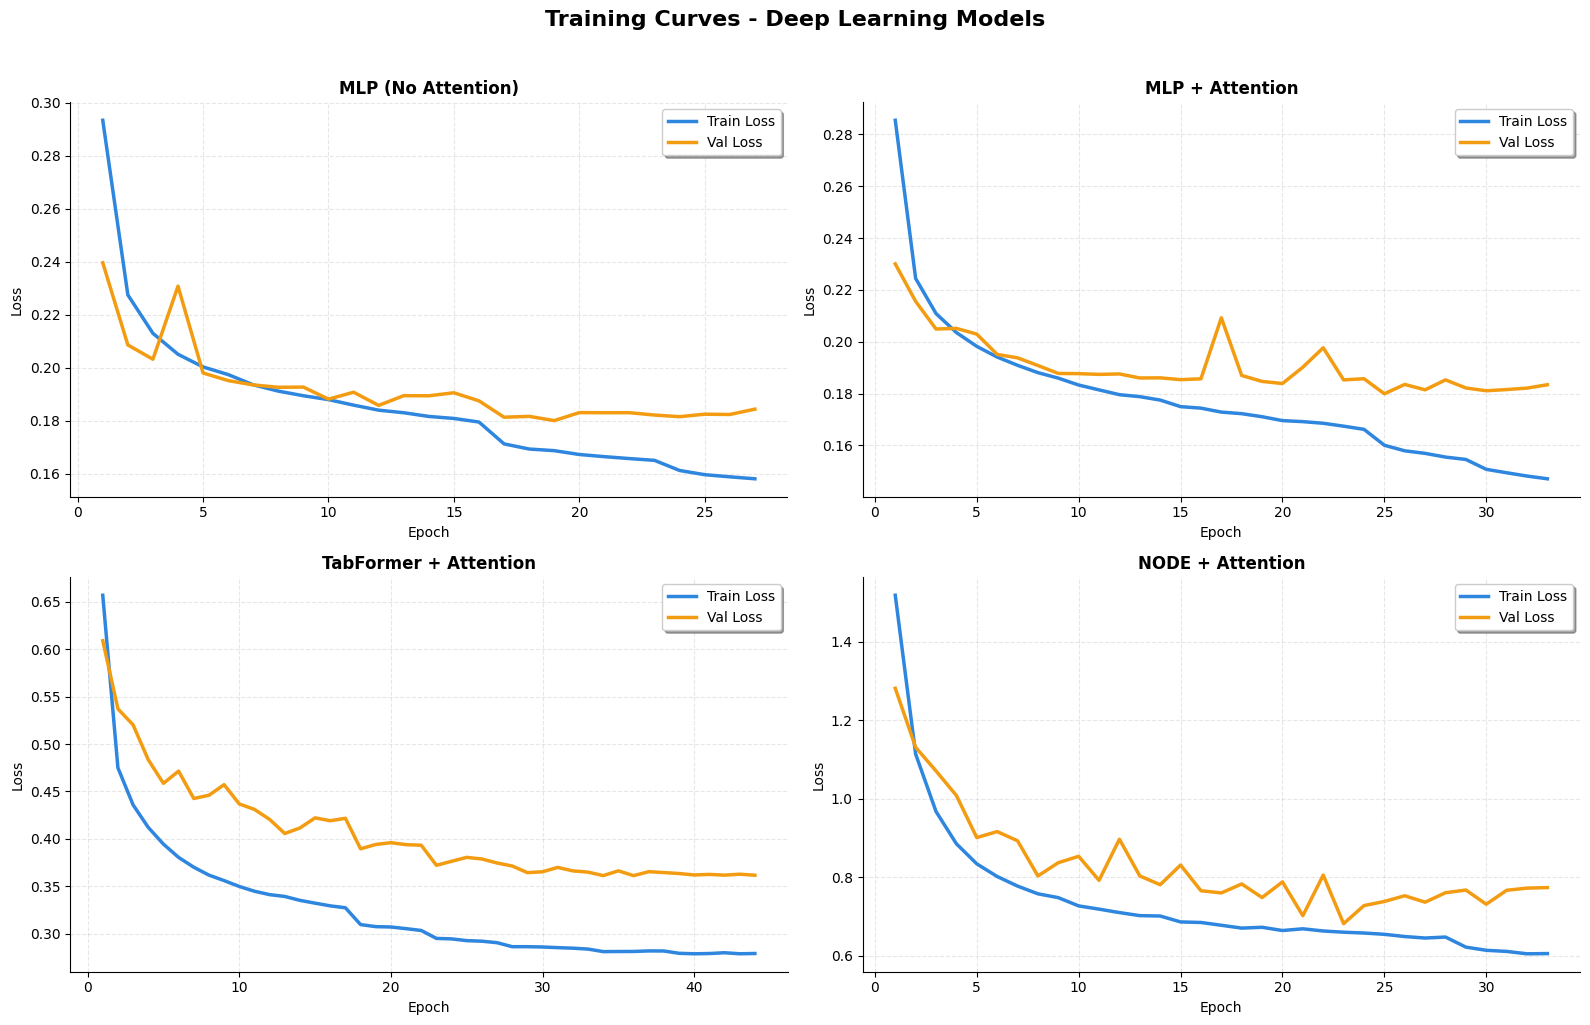

In [130]:
# ======================================
# VISUALIZATIONS
# ======================================
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# -----------------------------
# 1. Training Curves (Smooth Lines)
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))  # 2x2 grid for 4 models
axes = axes.flatten()

colors_train = '#2E86DE'  # Blue
colors_val = '#F39C12'    # Orange

for idx, result in enumerate(dl_results):
    history = result['History']
    ax = axes[idx]

    # Determine if Keras History object or dict (TabFormer/NODE)
    if hasattr(history, 'history'):
        epochs = range(1, len(history.history['loss']) + 1)
        train_loss = history.history['loss']
        val_loss = history.history['val_loss']
    else:
        epochs = range(1, len(history['loss']) + 1)
        train_loss = history['loss']
        val_loss = history['val_loss']

    ax.plot(epochs, train_loss, color=colors_train, linewidth=2.5, label='Train Loss')
    ax.plot(epochs, val_loss, color=colors_val, linewidth=2.5, label='Val Loss')

    ax.set_title(f"{result['Model']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Training Curves - Deep Learning Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


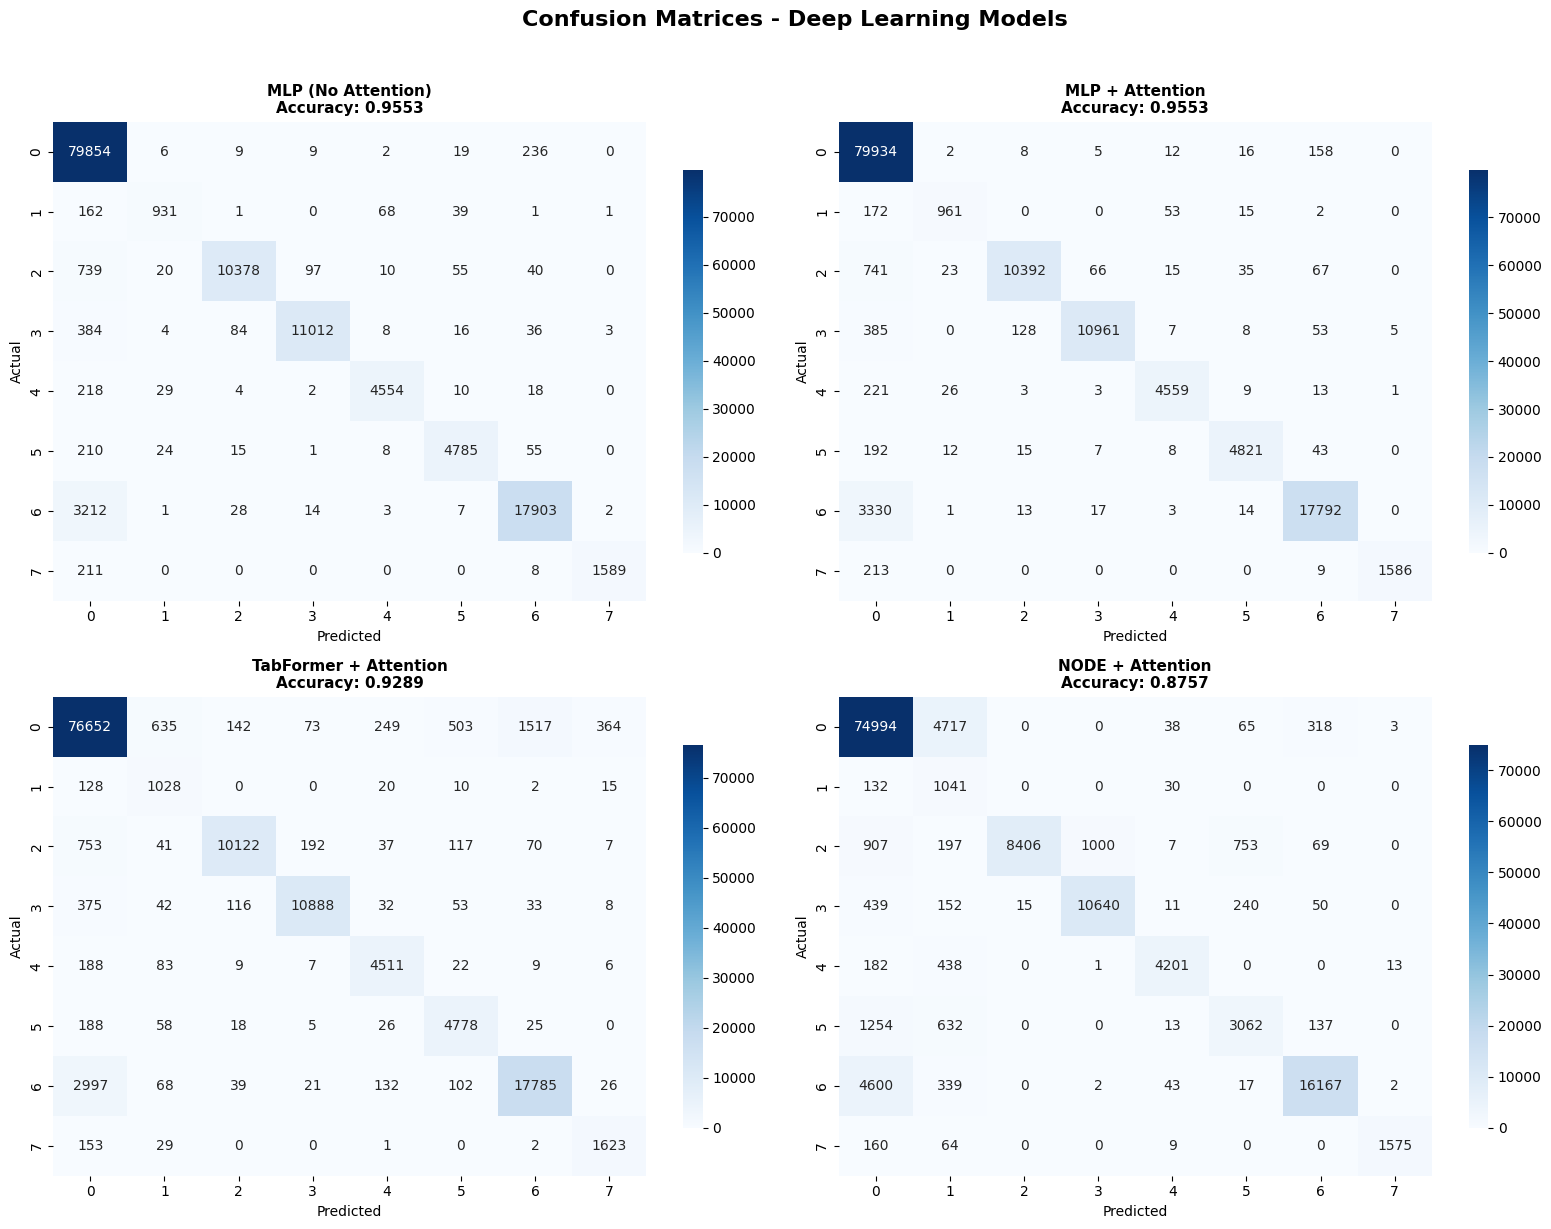

In [131]:
# -----------------------------
# 2. Confusion Matrices
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # 2x2 grid
axes = axes.flatten()

for idx, result in enumerate(dl_results):
    cm = confusion_matrix(y_test_dl, result['Predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f"{result['Model']}\nAccuracy: {result['Accuracy']:.4f}",
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - Deep Learning Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


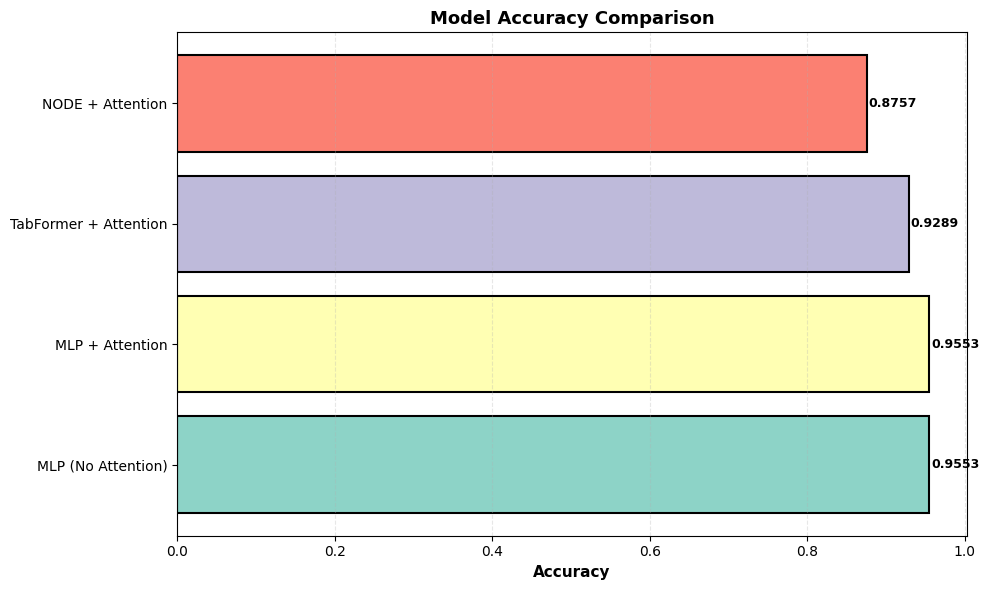

In [132]:
# -----------------------------
# 3. Final Comprehensive Comparison (Accuracy Bar Chart)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

model_names = [r['Model'] for r in dl_results]
accuracies = [r['Accuracy'] for r in dl_results]
colors = plt.cm.Set3(range(len(model_names)))

bars = ax.barh(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

for bar, val in zip(bars, accuracies):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


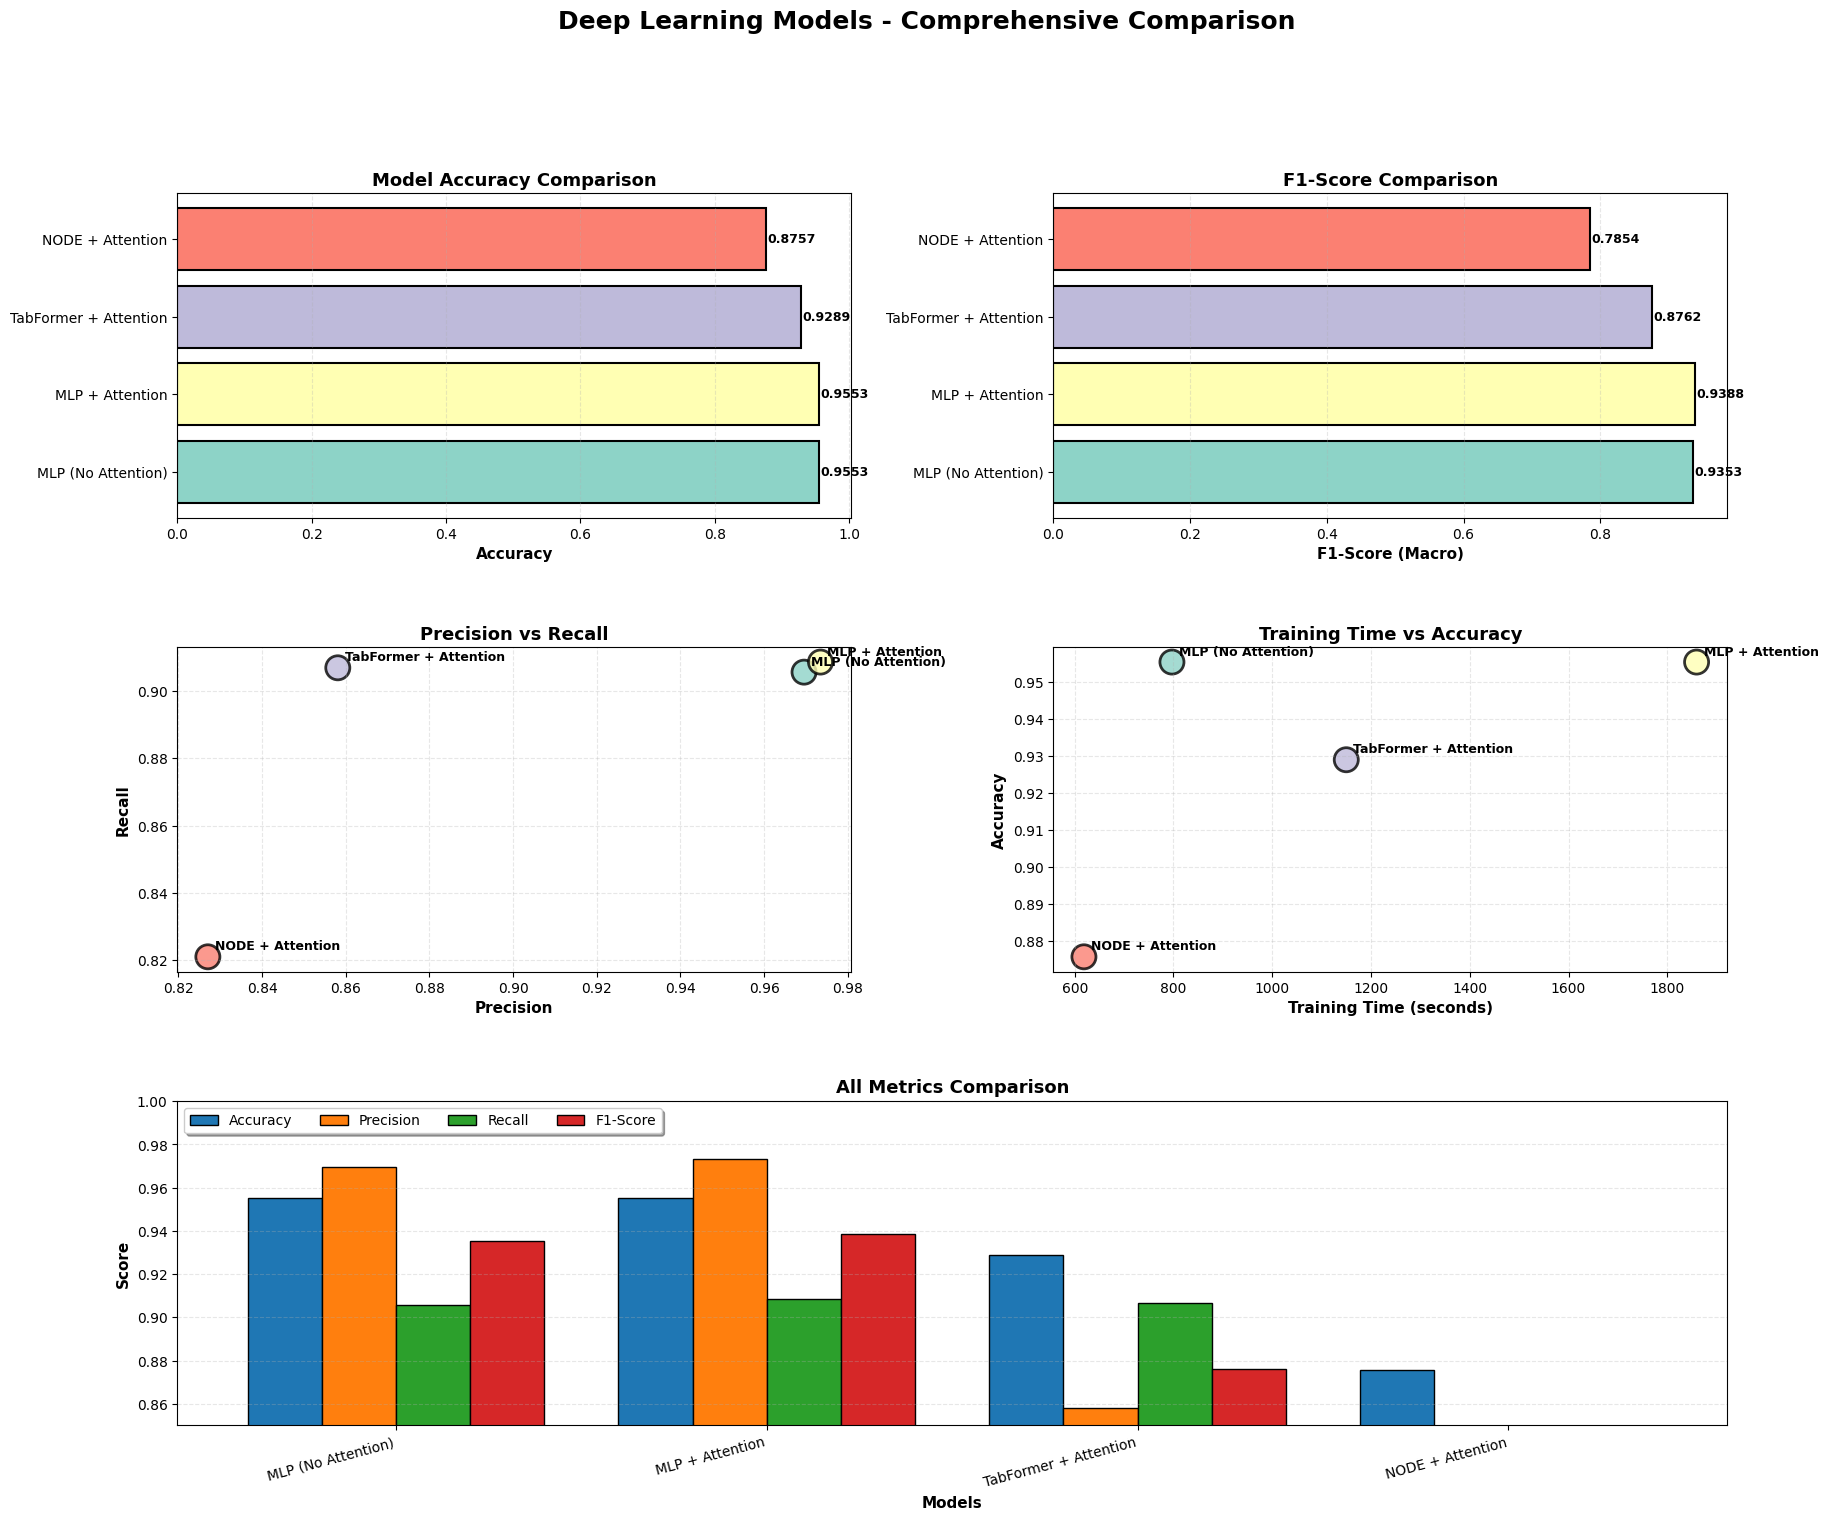


✓ All visualizations generated successfully!


In [143]:
# -----------------------------
# Setup for 6-panel comprehensive figure
# -----------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

model_names = [r['Model'] for r in dl_results]
colors = plt.cm.Set3(range(len(model_names)))

# Panel 1: Accuracy Bar Chart
ax1 = fig.add_subplot(gs[0, 0])
accuracies = [r['Accuracy'] for r in dl_results]
bars = ax1.barh(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for bar, val in zip(bars, accuracies):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Panel 2: F1-Score Bar Chart
ax2 = fig.add_subplot(gs[0, 1])
f1_scores = [r['F1_macro'] for r in dl_results]
bars = ax2.barh(model_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('F1-Score (Macro)', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for bar, val in zip(bars, f1_scores):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Panel 3: Precision vs Recall Scatter
ax3 = fig.add_subplot(gs[1, 0])
precisions = [r['Precision'] for r in dl_results]
recalls = [r['Recall'] for r in dl_results]
ax3.scatter(precisions, recalls, s=300, c=colors, edgecolor='black', linewidth=2, alpha=0.8)
for i, name in enumerate(model_names):
    ax3.annotate(name, (precisions[i], recalls[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax3.set_xlabel('Precision', fontsize=11, fontweight='bold')
ax3.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax3.set_title('Precision vs Recall', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

# Panel 4: Training Time vs Accuracy
ax4 = fig.add_subplot(gs[1, 1])
times = [r['Training_Time'] for r in dl_results]
ax4.scatter(times, accuracies, s=300, c=colors, edgecolor='black', linewidth=2, alpha=0.8)
for i, name in enumerate(model_names):
    ax4.annotate(name, (times[i], accuracies[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax4.set_xlabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax4.set_title('Training Time vs Accuracy', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')

# Panel 5: All Metrics Grouped Bar Chart
ax5 = fig.add_subplot(gs[2, :])
metrics_data = {
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
}
x = np.arange(len(model_names))
width = 0.2
multiplier = 0

for metric, values in metrics_data.items():
    offset = width * multiplier
    bars = ax5.bar(x + offset, values, width, label=metric, edgecolor='black', linewidth=1)
    multiplier += 1

ax5.set_ylabel('Score', fontsize=11, fontweight='bold')
ax5.set_xlabel('Models', fontsize=11, fontweight='bold')
ax5.set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x + width * 1.5)
ax5.set_xticklabels(model_names, rotation=15, ha='right')
ax5.legend(loc='upper left', ncol=4, frameon=True, shadow=True)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.set_ylim(0.85, 1.0)

plt.suptitle('Deep Learning Models - Comprehensive Comparison', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ All visualizations generated successfully!")
